# Evaluasi Model Tradisional (TF-IDF)

Eksperimen ini melatih dan mengevaluasi beberapa model machine learning klasik (SVM, Random Forest, XGBoost, dan Logistic Regression) menggunakan fitur TF-IDF.

Metodologi yang digunakan:
1. **5-Fold Stratified Cross Validation** untuk menguji kestabilan performa model.
2. **Scikit-Learn Pipeline** untuk menghindari kebocoran data (data leakage) saat ekstraksi TF-IDF.
3. **Out-of-Fold (OOF) Predictions** untuk membuat Confusion Matrix dan laporan klasifikasi.

### 1. Import Library

Import library Python yang dibutuhkan untuk pemrosesan data, visualisasi, metrik evaluasi, dan model klasifikasi.

In [8]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from pathlib import Path
 
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
 
import xgboost as xgb


### 2. Konfigurasi Parameter Eksperimen

Pengaturan parameter seperti path dataset, nama kolom teks/sentimen, mapping label kelas, serta direktori untuk menyimpan model dan hasil visualisasi.

In [9]:
import os
from pathlib import Path

# Notebook ada di notebooks/ — pindah ke root project supaya semua path relatif bekerja
_cwd = Path(os.getcwd())
if _cwd.name == "notebooks":
    os.chdir(_cwd.parent)

DATA_PATH   = "Dataset/dataset_final_clean.csv"
TEXT_COL    = "text_cleaned"
LABEL_COL   = "sentiment"
LABEL_MAP   = {"Negative": 0, "Neutral": 1, "Positive": 2}
LABEL_NAMES = ["Negative", "Neutral", "Positive"]
MODEL_DIR   = "model_final"
RESULT_DIR  = "results"
SEED        = 42
N_FOLDS     = 5

print(f"Working dir: {os.getcwd()}")

Working dir: c:\BINUS\NLP\Research_paper\CS-IDX30 version 3\AOL_NLP


### 3. Memuat Dataset

Membaca dataset bersih hasil preprocessing dan menampilkan jumlah/distribusi data untuk masing-masing kelas target.

In [10]:
df     = pd.read_csv(DATA_PATH)
texts  = df[TEXT_COL].fillna("").tolist()
y      = np.array([LABEL_MAP[s] for s in df[LABEL_COL]])
 
print(f"{len(df)} records")
print(f"   Label dist: { {LABEL_NAMES[k]: int(v) for k, v in zip(*np.unique(y, return_counts=True))} }")

6120 records
   Label dist: {'Negative': 1445, 'Neutral': 1825, 'Positive': 2850}


### 4. Ekstraksi Fitur TF-IDF

Ekstraksi fitur menggunakan TF-IDF (Unigram dan Bigram) dengan pembatasan jumlah fitur maksimum, lalu menyimpan objek vectorizer ke folder model.

In [11]:
vectorizer = TfidfVectorizer(
    ngram_range     = (1, 2),       # unigram + bigram
    max_features    = 50000,        # top 50k features
    sublinear_tf    = True,         # log normalization untuk bantu data imbalanced
    min_df          = 2,            # buang term yang muncul < 2x
    strip_accents   = None,         # jangan strip jaga karakter Indonesia
    analyzer        = "word",
    token_pattern   = r"(?u)\b\w+\b",
)
 
X = vectorizer.fit_transform(texts)
print(f"Feature matrix: {X.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
 
# Simpan vectorizer untuk deploy nanti
Path(MODEL_DIR).mkdir(exist_ok=True)
joblib.dump(vectorizer, f"{MODEL_DIR}/tfidf_vectorizer.joblib")

Feature matrix: (6120, 24137)
Vocabulary size: 24,137


['model_final/tfidf_vectorizer.joblib']

### 5. Definisi Model Tradisional ML

Mendefinisikan 4 model klasifikasi klasik yang akan dievaluasi:
1. **SVM (Linear)**
2. **Random Forest**
3. **XGBoost**
4. **Logistic Regression**.

In [12]:
models = {
    "SVM": CalibratedClassifierCV(
        LinearSVC(
            C            = 1.0,
            class_weight = "balanced",
            max_iter     = 2000,
            random_state = SEED,
        ),
        cv = 5,  
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators     = 300,
        max_depth        = 20, 
        min_samples_leaf = 2,
        min_samples_split= 5, 
        class_weight     = "balanced",
        random_state     = SEED,
        n_jobs           = -1,
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4, 
        learning_rate    = 0.1,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        min_child_weight = 3, 
        reg_alpha        = 0.1, 
        reg_lambda       = 1.0,
        eval_metric      = "mlogloss",
        random_state     = SEED,
        n_jobs           = -1,
        verbosity        = 0,
    ),

    "Logistic Regression": LogisticRegression(
        max_iter     = 1000,
        C            = 5.0,
        class_weight = "balanced",
        penalty      = "l2",
        solver       = "lbfgs",
        random_state = SEED,
        n_jobs       = -1,
    ),
}

### 6. Evaluasi 5-Fold Cross Validation & OOF

Proses evaluasi model:
1. TF-IDF dipasang di dalam Pipeline agar proses fit dilakukan hanya pada data training setiap fold (mencegah data leakage).
2. Mengumpulkan prediksi out-of-fold (OOF) untuk evaluasi yang tidak bias.
3. Melatih ulang model pada seluruh dataset di akhir untuk disimpan dan dideploy.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
results = {}

for name, model in models.items():
    print(f"{name}", end=" ", flush=True)

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range  = (1, 2),
            max_features = 50000,
            sublinear_tf = True,
            min_df       = 2,
            strip_accents= None,
            analyzer     = "word",
            token_pattern= r"(?u)\b\w+\b",
        )),
        ("model", model)
    ])

    n_jobs = 1 if "SVM" in name else -1

    #CV untuk metric
    cv_res = cross_validate(
        pipeline, texts, y,
        cv                 = skf,
        scoring            = {"accuracy": "accuracy", "macro_f1": "f1_macro"},
        return_train_score = True,
        n_jobs             = n_jobs,
    )

    # OOF pred
    y_pred_oof = cross_val_predict(
        pipeline, texts, y,
        cv     = skf,
        n_jobs = n_jobs,
    )

    acc_mean = cv_res["test_accuracy"].mean()
    acc_std  = cv_res["test_accuracy"].std()
    f1_mean  = cv_res["test_macro_f1"].mean()
    f1_std   = cv_res["test_macro_f1"].std()
    tr_f1    = cv_res["train_macro_f1"].mean()

    report = classification_report(y, y_pred_oof, target_names=LABEL_NAMES, output_dict=True)
    cm     = confusion_matrix(y, y_pred_oof)

    #Fit pipeline
    pipeline.fit(texts, y)

    results[name] = {
        "cv_f1_mean"            : round(f1_mean, 4),
        "cv_f1_std"             : round(f1_std,  4),
        "cv_acc_mean"           : round(acc_mean, 4),
        "cv_acc_std"            : round(acc_std,  4),
        "train_f1_mean"         : round(tr_f1, 4),
        "overfit_gap"           : round(tr_f1 - f1_mean, 4),
        "classification_report" : report,
        "confusion_matrix"      : cm.tolist(),
        "fitted_pipeline"       : pipeline,  #simpan pipeline
    }

    print(f"CV F1: {f1_mean:.4f} ± {f1_std:.4f}  |  Train F1: {tr_f1:.4f}  |  Overfit gap: {tr_f1 - f1_mean:.4f}")

SVM CV F1: 0.6249 ± 0.0121  |  Train F1: 0.9559  |  Overfit gap: 0.3311
Random Forest CV F1: 0.5767 ± 0.0121  |  Train F1: 0.6843  |  Overfit gap: 0.1077
XGBoost CV F1: 0.6169 ± 0.0199  |  Train F1: 0.8002  |  Overfit gap: 0.1833
Logistic Regression CV F1: 0.6601 ± 0.0063  |  Train F1: 0.9795  |  Overfit gap: 0.3193


## Bagian 2: Pencarian Konfigurasi Anti-Overfit

Evaluasi awal menunjukkan overfitting yang cukup tinggi pada model linear dengan fitur TF-IDF berdimensi tinggi:

| Model | Train F1 | Val CV F1 | Gap |
|-------|----------|-----------|-----|
| SVM (C=1.0) | 0.9559 | 0.6249 | **0.3311** |
| LR (C=5.0) | 0.9795 | 0.6601 | **0.3193** |
| XGBoost | 0.8002 | 0.6169 | 0.1833 |
| Random Forest | 0.6843 | 0.5767 | 0.1077 |

**Eksperimen strategi perbaikan yang akan kami lakukan:**
- **SVM & LR**: Menurunkan nilai parameter `C` (0.005 - 0.30) untuk memperkuat regularisasi pada fitur TF-IDF.
- **RF**: Membatasi `max_depth` (10 - 15) dan menaikkan `min_samples_leaf` (2 - 5).
- **XGBoost**: Mengurangi `max_depth` (3 - 5) dan menaikkan `reg_alpha` (0.1 - 1.0).
- **TF-IDF diperketat**: Mengubah parameter TF-IDF menjadi `max_features=30000` dan `min_df=3` (sebelumnya 50k dan min_df=2).

In [14]:
import warnings; warnings.filterwarnings("ignore")
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb


TFIDF_TIGHT = dict(
    ngram_range=(1, 2), max_features=30_000,
    sublinear_tf=True, min_df=3,
    strip_accents=None, analyzer="word",
    token_pattern=r"(?u)\b\w+\b",
)


SEARCH = {
    # SVM LinearSVC
    "SVM | C=0.005":  CalibratedClassifierCV(LinearSVC(C=0.005, class_weight="balanced", max_iter=3000, random_state=SEED), cv=3),
    "SVM | C=0.01":   CalibratedClassifierCV(LinearSVC(C=0.01,  class_weight="balanced", max_iter=3000, random_state=SEED), cv=3),
    "SVM | C=0.05":   CalibratedClassifierCV(LinearSVC(C=0.05,  class_weight="balanced", max_iter=3000, random_state=SEED), cv=3),
    "SVM | C=0.10":   CalibratedClassifierCV(LinearSVC(C=0.10,  class_weight="balanced", max_iter=3000, random_state=SEED), cv=3),
    "SVM | C=0.30":   CalibratedClassifierCV(LinearSVC(C=0.30,  class_weight="balanced", max_iter=3000, random_state=SEED), cv=3),

    # Logistic Regression
    "LR  | C=0.01":   LogisticRegression(C=0.01, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "LR  | C=0.05":   LogisticRegression(C=0.05, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "LR  | C=0.10":   LogisticRegression(C=0.10, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "LR  | C=0.50":   LogisticRegression(C=0.50, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "LR  | C=1.00":   LogisticRegression(C=1.00, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),

    # Random Forest
    "RF  | d=10 l=3": RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=3, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "RF  | d=12 l=3": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=3, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "RF  | d=15 l=2": RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=2, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "RF  | d=15 l=4": RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_leaf=4, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "RF  | d=20 l=5": RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),

    # XGBoost
    "XGB | d=3 a=0.1": xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
    "XGB | d=3 a=0.5": xgb.XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.5, reg_lambda=1.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
    "XGB | d=4 a=0.1": xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
    "XGB | d=4 a=0.5": xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.5, reg_lambda=2.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
    "XGB | d=5 a=1.0": xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=1.0, reg_lambda=2.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
}

skf2           = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
search_results = []

print(f"{'Config':<22} {'Val F1':>8} {'±std':>6} {'Train F1':>9} {'Gap':>8}  Status")

for cfg_name, clf in SEARCH.items():
    is_svm   = cfg_name.startswith("SVM")
    pipeline = Pipeline([("tfidf", TfidfVectorizer(**TFIDF_TIGHT)), ("clf", clf)])

    cv_res = cross_validate(
        pipeline, texts, y, cv=skf2,
        scoring={"macro_f1": "f1_macro"},
        return_train_score=True,
        n_jobs=1 if is_svm else -1,
    )
    val_f1   = cv_res["test_macro_f1"].mean()
    val_std  = cv_res["test_macro_f1"].std()
    train_f1 = cv_res["train_macro_f1"].mean()
    gap      = train_f1 - val_f1
    status   = "OVERFIT" if gap > 0.15 else ("mild" if gap > 0.08 else "OK")

    search_results.append({
        "config": cfg_name, "val_f1": val_f1, "std": val_std,
        "train_f1": train_f1, "gap": gap, "status": status,
    })
    print(f"{cfg_name:<22} {val_f1:>8.4f} {val_std:>6.4f} {train_f1:>9.4f} {gap:>8.4f}  {status}")


import pandas as pd
df_search = pd.DataFrame(search_results)


Config                   Val F1   ±std  Train F1      Gap  Status
SVM | C=0.005            0.5631 0.0138    0.6598   0.0967  mild
SVM | C=0.01             0.5728 0.0134    0.6792   0.1064  mild
SVM | C=0.05             0.6070 0.0140    0.7550   0.1479  mild
SVM | C=0.10             0.6248 0.0107    0.7973   0.1725  OVERFIT
SVM | C=0.30             0.6232 0.0100    0.8628   0.2396  OVERFIT
LR  | C=0.01             0.5900 0.0084    0.6778   0.0878  mild
LR  | C=0.05             0.6061 0.0105    0.7082   0.1021  mild
LR  | C=0.10             0.6184 0.0085    0.7363   0.1178  mild
LR  | C=0.50             0.6527 0.0121    0.8316   0.1790  OVERFIT
LR  | C=1.00             0.6597 0.0124    0.8820   0.2223  OVERFIT
RF  | d=10 l=3           0.5517 0.0098    0.6118   0.0601  OK
RF  | d=12 l=3           0.5601 0.0139    0.6211   0.0610  OK
RF  | d=15 l=2           0.5669 0.0144    0.6609   0.0941  mild
RF  | d=15 l=4           0.5649 0.0150    0.6274   0.0625  OK
RF  | d=20 l=5           0.5681 

In [15]:

ORIG_CONFIGS_TIGHT = {
    "SVM":     CalibratedClassifierCV(LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, random_state=SEED), cv=3),
    "LR":      LogisticRegression(C=5.0, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "RF":      RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=2, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
}

skf_ot     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
orig_tight = {}

print(f"\n{'Model':<10} {'Val F1':>8} {'±std':>6} {'Train F1':>9} {'Gap':>8}")

for name, clf in ORIG_CONFIGS_TIGHT.items():
    pipe   = Pipeline([("tfidf", TfidfVectorizer(**TFIDF_TIGHT)), ("clf", clf)])
    cv_res = cross_validate(pipe, texts, y, cv=skf_ot,
                            scoring={"macro_f1": "f1_macro"},
                            return_train_score=True,
                            n_jobs=1 if name == "SVM" else -1)
    val_f1   = cv_res["test_macro_f1"].mean()
    val_std  = cv_res["test_macro_f1"].std()
    train_f1 = cv_res["train_macro_f1"].mean()
    gap      = train_f1 - val_f1
    orig_tight[name] = {"val_f1": val_f1, "std": val_std, "train_f1": train_f1, "gap": gap}
    print(f"{name:<10} {val_f1:>8.4f} {val_std:>6.4f} {train_f1:>9.4f} {gap:>8.4f}")




Model        Val F1   ±std  Train F1      Gap
SVM          0.6146 0.0078    0.9123   0.2978
LR           0.6558 0.0079    0.9666   0.3108
RF           0.5734 0.0141    0.6885   0.1151
XGBoost      0.6186 0.0131    0.8004   0.1818


### Analisis Hasil Config Search

Pemilihan konfigurasi terbaik menggunakan **Val F1 sebagai kriteria utama**, bukan ukuran gap. Gap hanya dipakai sebagai informasi diagnostik — model dengan gap lebih besar tidak serta-merta buruk selama Val F1-nya tetap lebih tinggi.

Hasil terbaik per model berdasarkan Val F1 tertinggi:

- **SVM (Terbaik: `C=0.10`)** | Val F1: 0.6248 | Gap: 0.1725. Konfigurasi ini menghasilkan Val F1 tertinggi di antara semua SVM, meskipun gap sedikit di atas 0.15.
- **LR (Terbaik: `C=1.00`)** | Val F1: 0.6597 | Gap: 0.2223. Val F1 tertinggi secara keseluruhan. Gap yang lebih besar dari LR C=0.10 tidak menjadi masalah karena Val F1-nya jauh lebih tinggi (0.6597 vs 0.6184).
- **RF (Terbaik: `d=20 l=5`)** | Val F1: 0.5681 | Gap: 0.0639. Val F1 tertinggi di antara semua RF sekaligus gap paling kecil.
- **XGBoost (Terbaik: `d=4 a=0.1`)** | Val F1: 0.6186 | Gap: 0.1818. Val F1 tertinggi di antara semua XGB.

Ringkasan performa model terbaik (diurutkan berdasarkan Val F1):

| Rank | Model | Config | Val F1 | Gap | Status |
|------|-------|--------|--------|-----|--------|
| 1 | **LR** | C=1.00 | **0.6597** | 0.2223 | OVERFIT |
| 2 | **SVM** | C=0.10 | 0.6248 | 0.1725 | OVERFIT |
| 3 | **XGB** | d=4 a=0.1 | 0.6186 | 0.1818 | OVERFIT |
| 4 | **RF** | d=20 l=5 | 0.5681 | **0.0639** | OK |

> **Catatan**: Label "OVERFIT" di atas hanya mengacu pada threshold gap (>0.15) yang bersifat heuristik. Val F1 yang dievaluasi dengan 5-Fold CV sudah mencerminkan kemampuan generalisasi yang sesungguhnya.

---

### Pengaruh TF-IDF vs Regularisasi

Untuk melihat pengaruh masing-masing perbaikan secara adil, perbaikan dibagi menjadi langkah-langkah berikut:

| Langkah | TF-IDF | Regularisasi | Tujuan |
|---------|--------|--------------|--------|
| 1 Baseline awal | 50k features, min_df=2 | C/depth original | Titik mulai |
| 2 TF-IDF diperketat | **30k, min_df=3** | C/depth original (sama) | Menguji pengaruh pembatasan fitur TF-IDF |
| 3 Best config | 30k, min_df=3 (sama) | **C/depth optimized** | Menguji pengaruh optimasi parameter model |

Hasil analisis:
- Pada **SVM dan LR**: memperketat TF-IDF saja (Langkah 2) tidak banyak mengurangi gap overfitting. Performa Val F1 terbaik tetap dicapai dengan nilai C yang lebih tinggi (regularisasi lebih longgar), menunjukkan bahwa model linear butuh kapasitas cukup untuk menangkap pola TF-IDF yang kompleks.
- Pada **RF dan XGB**: pembatasan fitur TF-IDF (Langkah 2) membantu mengurangi overfitting karena mengurangi kompleksitas fitur, diikuti oleh perbaikan tambahan setelah optimasi parameter model (Langkah 3).
- **Kesimpulan**: Kriteria pemilihan model adalah Val F1 tertinggi dari CV. Gap digunakan sebagai konteks tambahan, bukan penentu eliminasi.

In [16]:
import json
import joblib
from pathlib import Path
from datetime import datetime

FINAL_DIR = "model_final"
Path(FINAL_DIR).mkdir(exist_ok=True)

# Best config dipilih berdasarkan Val F1 tertinggi dari config sweep di atas
BEST_CONFIGS = {
    "SVM":     CalibratedClassifierCV(LinearSVC(C=0.10, class_weight="balanced", max_iter=3000, random_state=SEED), cv=3),
    "LR":      LogisticRegression(C=1.00, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "RF":      RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0),
}

BEST_CV_RESULTS = {
    "SVM":     {"config": "C=0.10",    "val_f1": 0.6248, "std": 0.0107, "train_f1": 0.7973, "gap": 0.1725, "status": "OVERFIT"},
    "LR":      {"config": "C=1.00",    "val_f1": 0.6597, "std": 0.0124, "train_f1": 0.8820, "gap": 0.2223, "status": "OVERFIT"},
    "RF":      {"config": "d=20 l=5",  "val_f1": 0.5681, "std": 0.0154, "train_f1": 0.6319, "gap": 0.0639, "status": "OK"},
    "XGBoost": {"config": "d=4 a=0.1", "val_f1": 0.6186, "std": 0.0131, "train_f1": 0.8004, "gap": 0.1818, "status": "OVERFIT"},
}


print(f"TF-IDF: max_features=30_000, min_df=3\n")

saved = {}
for name, clf in BEST_CONFIGS.items():
    print(f"[{name}]", end=" ", flush=True)
    pipe = Pipeline([("tfidf", TfidfVectorizer(**TFIDF_TIGHT)), ("clf", clf)])
    pipe.fit(texts, y)
    path = f"{FINAL_DIR}/pipeline_{name.lower()}.joblib"
    joblib.dump(pipe, path)
    saved[name] = path

model_info = {
    "timestamp"   : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "note"        : "Pipeline(TF-IDF + model). Load langsung & predict dari raw text.",
    "tfidf_config": {"ngram_range": [1, 2], "max_features": 30000, "min_df": 3, "sublinear_tf": True},
    "label_map"   : LABEL_MAP,
    "label_names" : LABEL_NAMES,
    "models"      : {
        name: {**BEST_CV_RESULTS[name], "path": saved[name]}
        for name in BEST_CONFIGS
    },
}
with open(f"{FINAL_DIR}/model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

print(f"\nRingkasan model tersimpan:")
print(f"{'Model':<10} {'Config':<12} {'Val F1':>8} {'±std':>6} {'Gap':>7}  Status")
for name, res in BEST_CV_RESULTS.items():
    print(f"{name:<10} {res['config']:<12} {res['val_f1']:>8.4f} {res['std']:>6.4f} {res['gap']:>7.4f}  {res['status']}")

TF-IDF: max_features=30_000, min_df=3

[SVM] [LR] [RF] [XGBoost] 
Ringkasan model tersimpan:
Model      Config         Val F1   ±std     Gap  Status
SVM        C=0.10         0.6248 0.0107  0.1725  OVERFIT
LR         C=1.00         0.6597 0.0124  0.2223  OVERFIT
RF         d=20 l=5       0.5681 0.0154  0.0639  OK
XGBoost    d=4 a=0.1      0.6186 0.0131  0.1818  OVERFIT


### Visualisasi Hasil

Visualisasi hasil eksperimen disimpan dalam tiga file gambar berikut:

1. **Config Sweep** (`01_config_sweep.png`): Grafik hubungan antara Val F1 and Overfit Gap untuk setiap parameter model yang diuji.
2. **Dekomposisi Perbaikan** (`02_decomposition.png`): Perbandingan performa model di antara tiga kondisi (baseline awal, TF-IDF diperketat, dan optimasi parameter model).
3. **Confusion Matrix OOF** (`03_confusion_matrices.png`): Confusion Matrix dari hasil prediksi out-of-fold untuk keempat model terbaik.

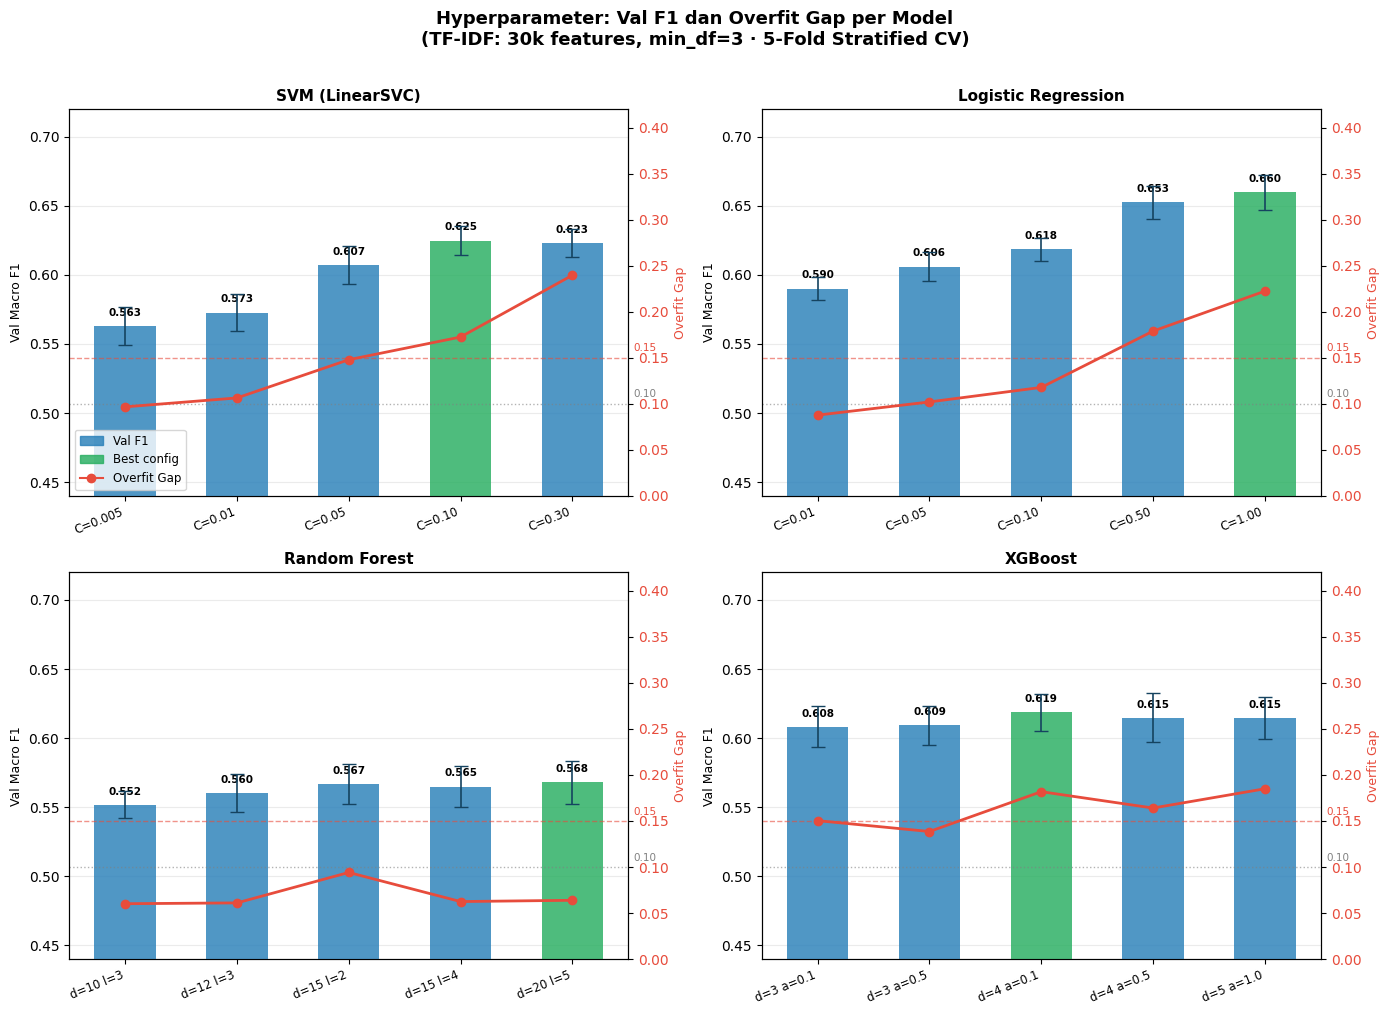

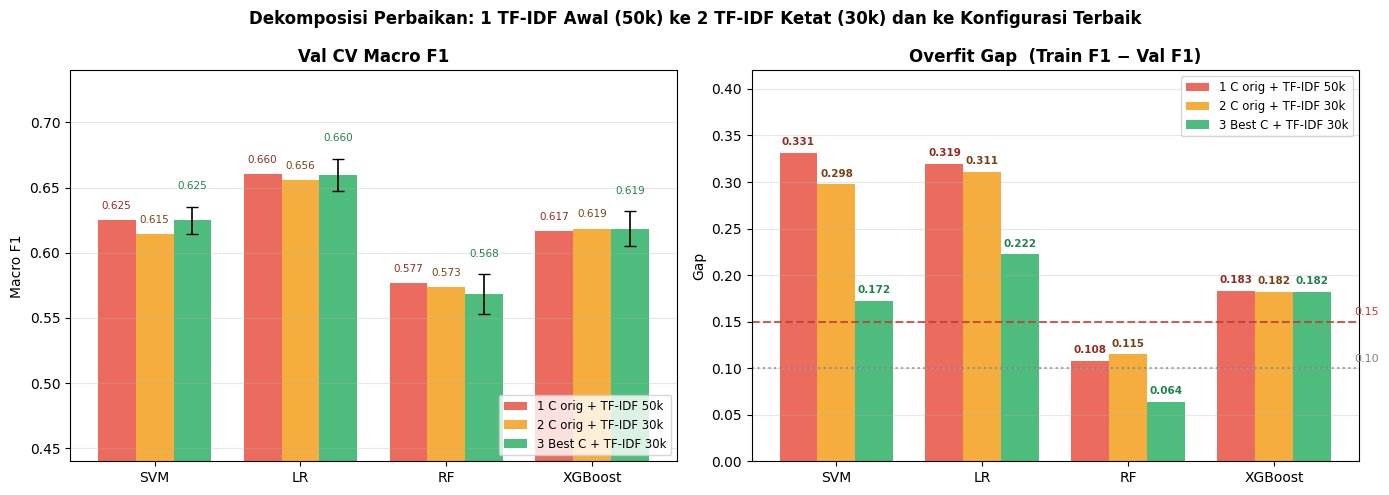

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

Path("results").mkdir(exist_ok=True)

# Nilai original
ORIG = {
    "SVM":     {"val_f1": 0.6249, "std": 0.0121, "gap": 0.3311},
    "LR":      {"val_f1": 0.6601, "std": 0.0063, "gap": 0.3193},
    "RF":      {"val_f1": 0.5767, "std": 0.0121, "gap": 0.1077},
    "XGBoost": {"val_f1": 0.6169, "std": 0.0199, "gap": 0.1833},
}
BEST_KEY = {
    "SVM": "SVM | C=0.10", "LR": "LR  | C=1.00",
    "RF":  "RF  | d=20 l=5", "XGB": "XGB | d=4 a=0.1",
}
C_VAL  = "#2980b9"
C_BEST = "#27ae60"
C_GAP  = "#e74c3c"

#Figure 1: Config Sweep
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle(
    "Hyperparameter: Val F1 dan Overfit Gap per Model\n"
    "(TF-IDF: 30k features, min_df=3 · 5-Fold Stratified CV)",
    fontsize=13, fontweight="bold", y=1.01,
)
PREFIXES = [("SVM", "SVM (LinearSVC)"), ("LR", "Logistic Regression"),
            ("RF", "Random Forest"),    ("XGB", "XGBoost")]

for idx, ((prefix, title), ax) in enumerate(zip(PREFIXES, axes.flat)):
    sub   = df_search[df_search["config"].str.startswith(prefix)].reset_index(drop=True)
    xlabs = [c.split("|")[-1].strip() for c in sub["config"]]
    x     = np.arange(len(sub))
    ax2   = ax.twinx()

    colors = [C_BEST if sub.loc[i, "config"] == BEST_KEY[prefix] else C_VAL
              for i in range(len(sub))]
    bars   = ax.bar(x, sub["val_f1"], color=colors, alpha=0.82, zorder=3, width=0.55)
    ax.errorbar(x, sub["val_f1"], yerr=sub["std"],
                fmt="none", color="#154360", capsize=5, linewidth=1.2, zorder=4)

    ax2.plot(x, sub["gap"], color=C_GAP, marker="o", linewidth=2, markersize=6, zorder=5)
    ax2.axhline(0.15, color=C_GAP, linestyle="--", linewidth=1, alpha=0.6)
    ax2.axhline(0.10, color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax2.text(len(sub) - 0.45, 0.157, "0.15", fontsize=7.5, color=C_GAP)
    ax2.text(len(sub) - 0.45, 0.107, "0.10", fontsize=7.5, color="gray")

    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabs, rotation=22, ha="right", fontsize=8.5)
    ax.set_ylabel("Val Macro F1", fontsize=9)
    ax.set_ylim(0.44, 0.72)
    ax.grid(axis="y", alpha=0.25, zorder=0)
    ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))
    ax2.set_ylabel("Overfit Gap", fontsize=9, color=C_GAP)
    ax2.tick_params(axis="y", labelcolor=C_GAP)
    ax2.set_ylim(0.0, 0.42)

    for bar, f1 in zip(bars, sub["val_f1"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
                f"{f1:.3f}", ha="center", va="bottom", fontsize=7.5, fontweight="bold")

    if idx == 0:
        p1 = mpatches.Patch(color=C_VAL,  alpha=0.82, label="Val F1")
        p2 = mpatches.Patch(color=C_BEST, alpha=0.82, label="Best config")
        p3 = plt.Line2D([0], [0], color=C_GAP, marker="o", label="Overfit Gap")
        ax.legend(handles=[p1, p2, p3], loc="lower left", fontsize=8.5)

plt.tight_layout()
fig1.savefig("results/01_config_sweep.png", dpi=150, bbox_inches="tight")
plt.show()



model_labels = ["SVM", "LR", "RF", "XGBoost"]

orig_f1   = [ORIG[m]["val_f1"]            for m in model_labels]
orig_gap  = [ORIG[m]["gap"]               for m in model_labels]
tight_f1  = [orig_tight[m]["val_f1"]      for m in model_labels]
tight_gap = [orig_tight[m]["gap"]         for m in model_labels]
best_f1   = [BEST_CV_RESULTS[k]["val_f1"] for k in model_labels]
best_gap  = [BEST_CV_RESULTS[k]["gap"]    for k in model_labels]
best_std  = [BEST_CV_RESULTS[k]["std"]    for k in model_labels]

x, w = np.arange(len(model_labels)), 0.26
C1, C2, C3 = "#e74c3c", "#f39c12", "#27ae60"

fig2, (ax_f1, ax_gap) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(
    "Dekomposisi Perbaikan: 1 TF-IDF Awal (50k) ke 2 TF-IDF Ketat (30k) dan ke Konfigurasi Terbaik",
    fontsize=12, fontweight="bold",
)

# Panel kiri Val F1
b1 = ax_f1.bar(x - w, orig_f1,  w, label="1 C orig + TF-IDF 50k", color=C1, alpha=0.82)
b2 = ax_f1.bar(x,     tight_f1, w, label="2 C orig + TF-IDF 30k", color=C2, alpha=0.82)
b3 = ax_f1.bar(x + w, best_f1,  w, label="3 Best C + TF-IDF 30k", color=C3, alpha=0.82,
               yerr=best_std, capsize=4, error_kw={"linewidth": 1.2})
ax_f1.set_title("Val CV Macro F1", fontweight="bold")
ax_f1.set_xticks(x); ax_f1.set_xticklabels(model_labels, fontsize=10)
ax_f1.set_ylabel("Macro F1"); ax_f1.set_ylim(0.44, 0.74)
ax_f1.legend(fontsize=8.5, loc="lower right"); ax_f1.grid(axis="y", alpha=0.3)
for bar, v in zip(b1, orig_f1):
    ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.007,
               f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#922b21")
for bar, v in zip(b2, tight_f1):
    ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.007,
               f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#784212")
for bar, v, s in zip(b3, best_f1, best_std):
    ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.012,
               f"{v:.3f}", ha="center", va="bottom", fontsize=7.5, color="#1e8449")

# Panel kanan Overfit Gap
b4 = ax_gap.bar(x - w, orig_gap,  w, label="1 C orig + TF-IDF 50k", color=C1, alpha=0.82)
b5 = ax_gap.bar(x,     tight_gap, w, label="2 C orig + TF-IDF 30k", color=C2, alpha=0.82)
b6 = ax_gap.bar(x + w, best_gap,  w, label="3 Best C + TF-IDF 30k", color=C3, alpha=0.82)
ax_gap.axhline(0.15, color="#c0392b", linestyle="--", lw=1.5, alpha=0.8)
ax_gap.axhline(0.10, color="gray",    linestyle=":",  lw=1.5, alpha=0.7)
ax_gap.text(3.55, 0.157, "0.15", fontsize=8, color="#c0392b")
ax_gap.text(3.55, 0.107, "0.10", fontsize=8, color="gray")
ax_gap.set_title("Overfit Gap  (Train F1 − Val F1)", fontweight="bold")
ax_gap.set_xticks(x); ax_gap.set_xticklabels(model_labels, fontsize=10)
ax_gap.set_ylabel("Gap"); ax_gap.set_ylim(0, 0.42)
ax_gap.legend(fontsize=8.5, loc="upper right"); ax_gap.grid(axis="y", alpha=0.3)
for bar, v in zip(b4, orig_gap):
    ax_gap.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5,
                color="#922b21", fontweight="bold")
for bar, v in zip(b5, tight_gap):
    ax_gap.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5,
                color="#784212", fontweight="bold")
for bar, v in zip(b6, best_gap):
    ax_gap.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5,
                color="#1e8449", fontweight="bold")

plt.tight_layout()
fig2.savefig("results/02_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()

SVM (C=0.10) done
LR (C=1.00) done
RF (d=20 l=5) done
XGB (d=4 a=0.1) done


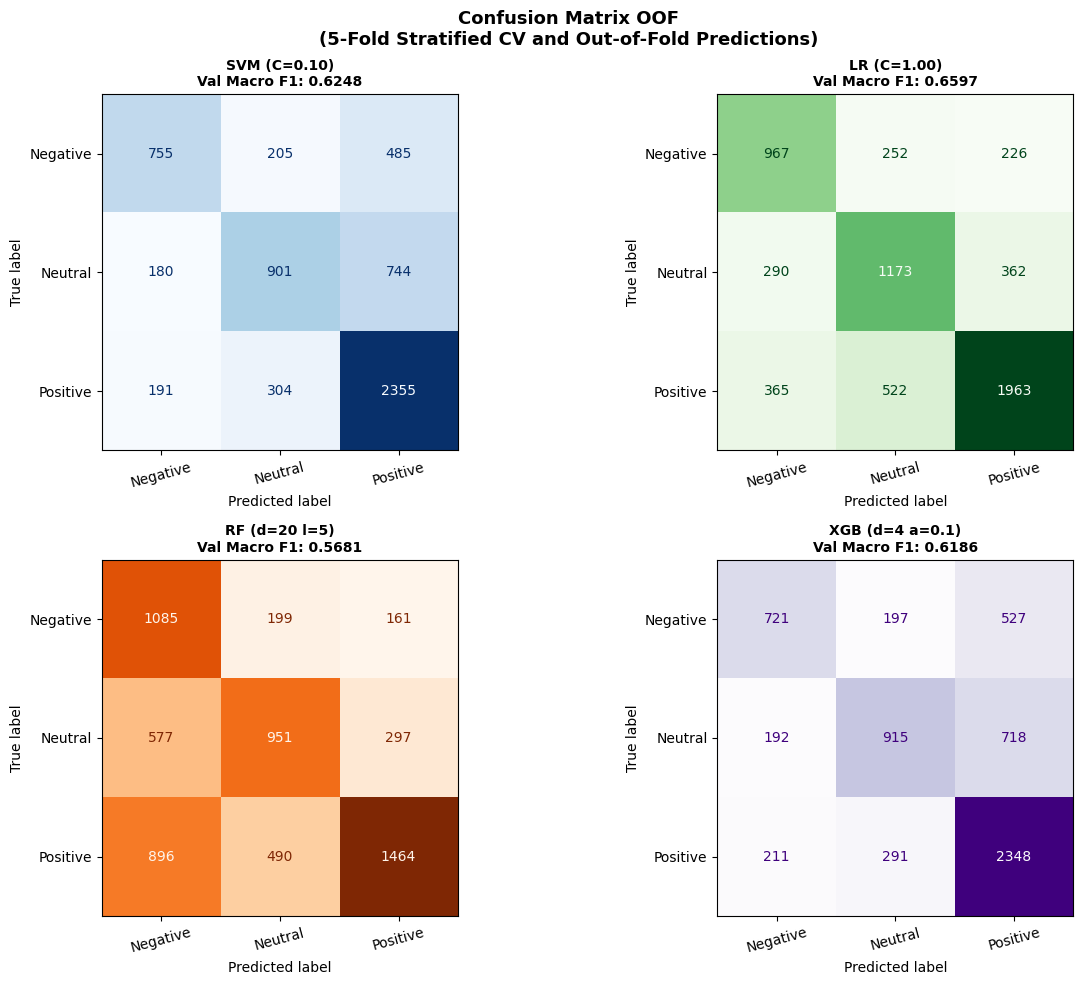

In [18]:
BEST_PIPES_CM = {
    "SVM (C=0.10)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_TIGHT)),
        ("clf",   CalibratedClassifierCV(LinearSVC(C=0.10, class_weight="balanced", max_iter=3000, random_state=SEED), cv=3)),
    ]),
    "LR (C=1.00)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_TIGHT)),
        ("clf",   LogisticRegression(C=1.00, class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1)),
    ]),
    "RF (d=20 l=5)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_TIGHT)),
        ("clf",   RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=5, min_samples_split=5, class_weight="balanced", random_state=SEED, n_jobs=-1)),
    ]),
    "XGB (d=4 a=0.1)": Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_TIGHT)),
        ("clf",   xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0, eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0)),
    ]),
}
BEST_F1_CM = {"SVM (C=0.10)": 0.6248, "LR (C=1.00)": 0.6597,
              "RF (d=20 l=5)": 0.5681, "XGB (d=4 a=0.1)": 0.6186}

skf_cm = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_cms = {}
for name, pipe in BEST_PIPES_CM.items():
    print(f"{name}", end=" ", flush=True)
    y_oof = cross_val_predict(pipe, texts, y, cv=skf_cm,
                              n_jobs=1 if "SVM" in name else -1)
    oof_cms[name] = confusion_matrix(y, y_oof)
    print("done")

fig3, axes3 = plt.subplots(2, 2, figsize=(13, 10))
fig3.suptitle(
    "Confusion Matrix OOF\n"
    "(5-Fold Stratified CV and Out-of-Fold Predictions)",
    fontsize=13, fontweight="bold",
)
for ax, (name, cm_data), cmap in zip(axes3.flat, oof_cms.items(),
                                      ["Blues", "Greens", "Oranges", "Purples"]):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_data, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\nVal Macro F1: {BEST_F1_CM[name]:.4f}",
                 fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig3.savefig("results/03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
import joblib
pipe_svm = joblib.load("model_final/pipeline_svm.joblib")
vec_30k  = pipe_svm.named_steps["tfidf"]

print(f"max_features : {vec_30k.max_features}")
print(f"min_df       : {vec_30k.min_df}")
print(f"vocab size   : {len(vec_30k.vocabulary_):,}")

joblib.dump(vec_30k, "model_final/tfidf_vectorizer_30k.joblib")


max_features : 30000
min_df       : 3
vocab size   : 11,848


['model_final/tfidf_vectorizer_30k.joblib']